***TASK 01 Pick a dataset and frame a question***

• Choose a real dataset — from the approved list below, or bring your own (must be approved first).

• Frame ONE clear analytical question it can answer. Not 'explore the data' — a real question, like 'what factors
most affect X?' or 'do groups A and B differ in Y?'

**The Main Question For the Project:-“Which thing is more affected to be patient for Heart Diasease? & can we prove it ?"**

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 4.5)

• Write two or three sentences on why the question matters and what you expect to find.

• Make sure the dataset is rich enough: at least a few hundred rows and several columns, with a mix of numeric
and categorical.


==>Heart disease and heart attacks are major health concerns.
This analysis will identify which factors are most strongly associated with heart disease
 and test whether these relationships are statistically significant.

***TASK 02 Load, clean, and run full EDA***

• Run the first-30-minutes checklist and document what you found.

In [3]:
df = pd.read_csv("heartv1.csv")


print("shape" , df.shape)
print("\ncolumns:", list(df.columns))
print("\nmissing values:\n",df.isnull().sum()[df.isnull().sum() > 0] )

shape (1035, 16)

columns: ['sex', 'age', 'cp', 'resting_BP', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'Max Heart Rate Reserve', 'Heart Disease Risk Score', 'target']

missing values:
 sex                         22
age                         30
cp                          16
resting_BP                  18
chol                        24
fbs                         12
restecg                     10
thalach                     25
exang                       16
oldpeak                     10
slope                       16
ca                          15
thal                        35
Max Heart Rate Reserve      16
Heart Disease Risk Score    11
dtype: int64


In [4]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1035 entries, 0 to 1034
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   sex                       1013 non-null   str    
 1   age                       1005 non-null   float64
 2   cp                        1019 non-null   float64
 3   resting_BP                1017 non-null   float64
 4   chol                      1011 non-null   float64
 5   fbs                       1023 non-null   float64
 6   restecg                   1025 non-null   float64
 7   thalach                   1010 non-null   float64
 8   exang                     1019 non-null   float64
 9   oldpeak                   1025 non-null   float64
 10  slope                     1019 non-null   float64
 11  ca                        1020 non-null   float64
 12  thal                      1000 non-null   float64
 13  Max Heart Rate Reserve    1019 non-null   float64
 14  Heart Disease Risk 

In [5]:
print("First 5 Rows of the Data",df.head())

First 5 Rows of the Data       sex   age   cp  resting_BP   chol  fbs  restecg  thalach  exang  \
0    male  65.0  0.0       130.0  254.0  0.0      0.0    147.0    0.0   
1    male  53.0  0.0       140.0  261.0  0.0      0.0    186.0    1.0   
2    male  50.0  0.0       122.0  222.0  0.0      0.0    186.0    0.0   
3  female  47.0  1.0       112.0  160.0  0.0      1.0    138.0    0.0   
4    male  47.0  0.0       142.0  309.0  0.0      0.0    147.0    1.0   

   oldpeak  slope   ca  thal  Max Heart Rate Reserve  \
0      1.4    1.0  1.0   3.0                    10.0   
1      0.0    2.0  0.0   2.0                   -17.0   
2      0.0    2.0  0.0   2.0                   -14.0   
3      0.0    1.0  0.0   2.0                    37.0   
4      0.0    1.0  3.0   3.0                    28.0   

   Heart Disease Risk Score  target  
0                     11.44       0  
1                     13.51       1  
2                      9.46       1  
3                      8.34       1  
4        

In [6]:
df.describe()

,age,cp,resting_BP,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,Max Heart Rate Reserve,Heart Disease Risk Score,target
count,1005.000000,1019.000000,1017.000000,1011.000000,1023.000000,1025.000000,1010.000000,1019.000000,1025.000000,1019.000000,1020.000000,1000.000000,1019.000000,1024.000000,1035.000000
mean,56.398010,1.000000,131.759095,245.734916,0.149560,0.530732,149.236634,0.337586,1.082439,1.385672,0.758824,2.370000,16.281649,11.890410,0.513043
std,9.065103,1.444453,17.468531,51.381190,0.356814,0.527822,22.975974,0.473119,1.177318,0.618502,1.027908,1.630877,21.076066,2.233617,0.500071
min,28.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-29.000000,7.540000,0.000000
25%,50.000000,0.000000,120.000000,211.000000,0.000000,0.000000,132.250000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000,10.190000,0.000000
50%,58.000000,1.000000,130.000000,239.000000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,12.000000,11.730000,1.000000
75%,63.000000,2.000000,140.000000,275.000000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,28.000000,13.580000,1.000000
max,79.000000,30.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,50.000000,82.000000,18.800000,1.000000


• Clean the data: handle missing values (and justify your strategy), fix types, remove or flag outliers. Write down
every cleaning decision

In [7]:
categorical_cols = [
    "sex", "cp", "fbs", "restecg",
    "exang", "slope", "ca", "thal"
]

numeric_cols = [
    "age", "resting_BP", "chol", "thalach",
    "oldpeak", "Max Heart Rate Reserve",
    "Heart Disease Risk Score"
]

# Fill categorical missing values with mode
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Fill numerical missing values with median
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

In [8]:
print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
sex                         0
age                         0
cp                          0
resting_BP                  0
chol                        0
fbs                         0
restecg                     0
thalach                     0
exang                       0
oldpeak                     0
slope                       0
ca                          0
thal                        0
Max Heart Rate Reserve      0
Heart Disease Risk Score    0
target                      0
dtype: int64


In [9]:
# Outlier Detection using IQR

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = ((df[col] < lower) | (df[col] > upper)).sum()

    print(f"{col}: {count} outliers")

'''Outlier Finding: Potential outliers were detected in several numerical variables, with the highest number in Resting BP (30), Cholesterol (15), and Max Heart Rate Reserve (13).

Decision

Outlier Decision: The detected values were retained because they can represent valid medical measurements. Only clearly invalid categorical values were corrected'''


age: 4 outliers
resting_BP: 30 outliers
chol: 15 outliers
thalach: 4 outliers
oldpeak: 7 outliers
Max Heart Rate Reserve: 13 outliers
Heart Disease Risk Score: 1 outliers


'Outlier Finding: Potential outliers were detected in several numerical variables, with the highest number in Resting BP (30), Cholesterol (15), and Max Heart Rate Reserve (13).\n\nDecision\n\nOutlier Decision: The detected values were retained because they can represent valid medical measurements. Only clearly invalid categorical values were corrected'

• Do univariate analysis on your key variables — distributions and shapes.

target
1    531
0    504
Name: count, dtype: int64

Percentage:
target
1    51.3
0    48.7
Name: proportion, dtype: float64


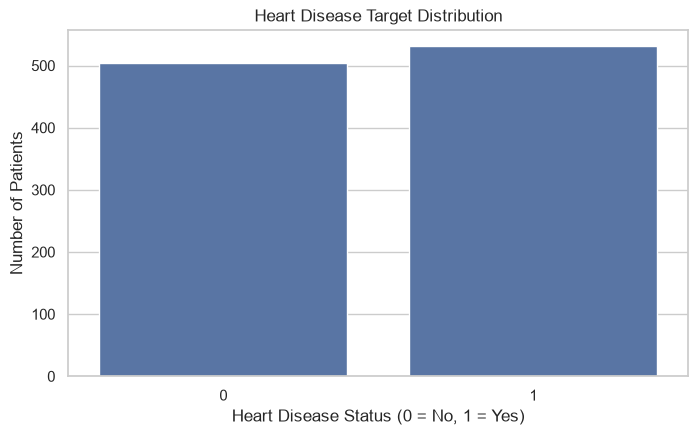

In [10]:
print(df["target"].value_counts())

print("\nPercentage:")
print(df["target"].value_counts(normalize=True).mul(100).round(2))


sns.countplot(data=df, x="target")

plt.title("Heart Disease Target Distribution")
plt.xlabel("Heart Disease Status (0 = No, 1 = Yes)")
plt.ylabel("Number of Patients")

plt.show()

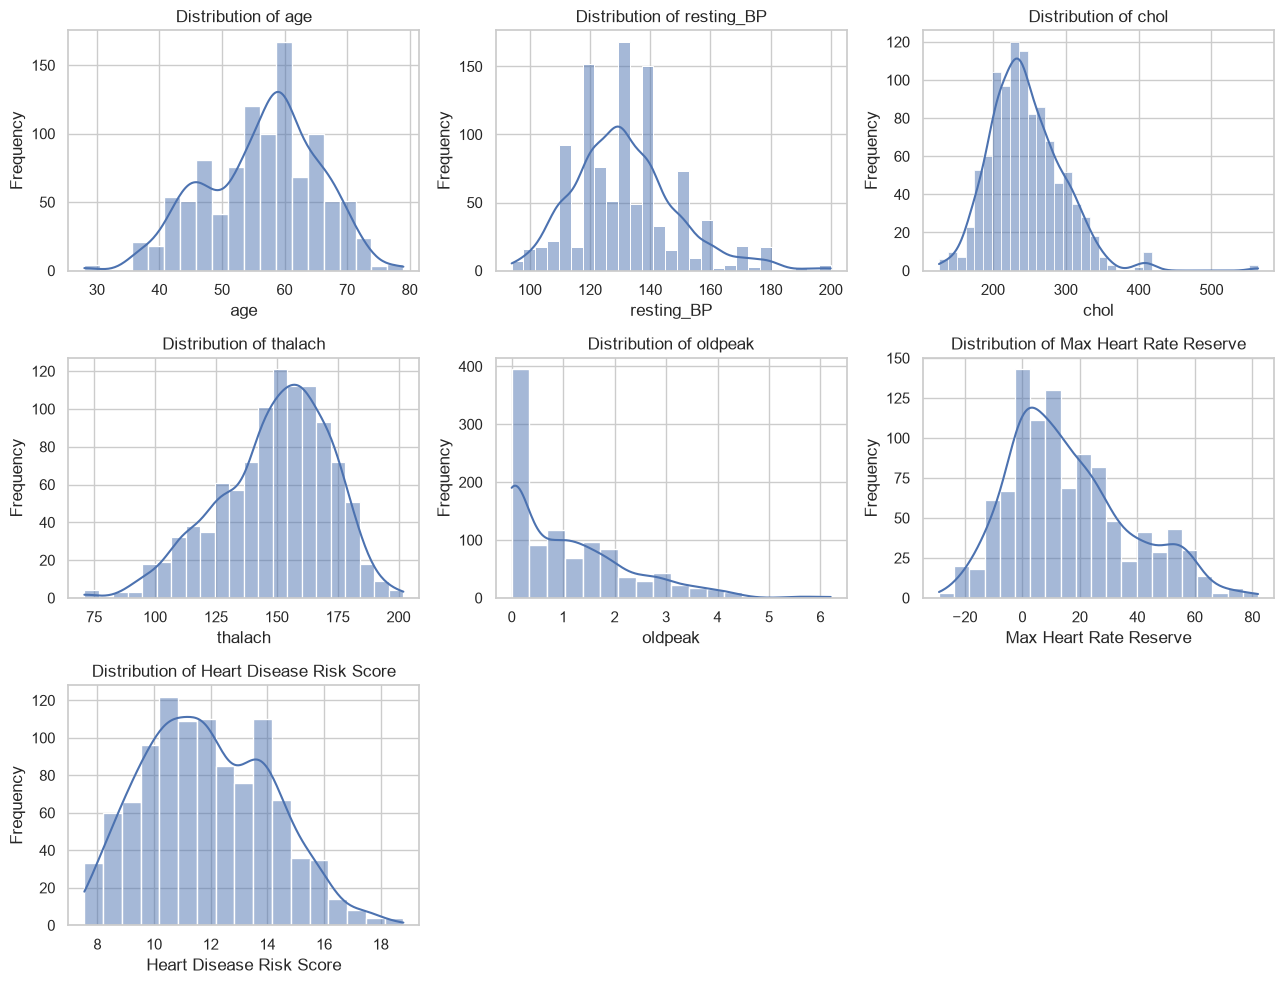

In [11]:
numeric_cols = [
    "age",
    "resting_BP",
    "chol",
    "thalach",
    "oldpeak",
    "Max Heart Rate Reserve",
    "Heart Disease Risk Score"
]

fig, axes = plt.subplots(3, 3, figsize=(13, 10))
axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")

# Hide unused plots
for ax in axes[len(numeric_cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

In [12]:
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
age,1035.0,56.444444,8.936676,28.00,50.00,58.00,63.00,79.0
resting_BP,1035.0,131.728502,17.317345,94.00,120.00,130.00,140.00,200.0
chol,1035.0,245.578744,50.791514,126.00,211.00,239.00,274.00,564.0
thalach,1035.0,149.303382,22.700487,71.00,133.50,152.00,165.00,202.0
oldpeak,1035.0,1.079710,1.171937,0.00,0.00,0.80,1.80,6.2
Max Heart Rate Reserve,1035.0,16.215459,20.919042,-29.00,0.00,12.00,28.00,82.0
Heart Disease Risk Score,1035.0,11.888705,2.221766,7.54,10.19,11.73,13.54,18.8


• Do bivariate and multivariate analysis — the relationships that bear on your question.

In [13]:
categorical_cols = [
    "sex", "cp", "fbs", "restecg",
    "exang", "slope", "ca", "thal"
]

for col in categorical_cols:
    print(f"\n--- {col} vs Heart Disease ---")
    print(
        pd.crosstab(
            df[col],
            df["target"],
            normalize="index"
        ).mul(100).round(2)
    )


--- sex vs Heart Disease ---
target      0      1
sex                 
female  27.24  72.76
male    57.95  42.05

--- cp vs Heart Disease ---
target       0       1
cp                    
0.0      74.36   25.64
1.0      20.36   79.64
2.0      23.38   76.62
3.0      34.62   65.38
7.0       0.00  100.00
8.0       0.00  100.00
10.0    100.00    0.00
30.0      0.00  100.00

--- fbs vs Heart Disease ---
target      0      1
fbs                 
0.0     48.19  51.81
1.0     51.63  48.37

--- restecg vs Heart Disease ---
target       0      1
restecg              
0.0      56.25  43.75
1.0      40.65  59.35
2.0      80.00  20.00

--- exang vs Heart Disease ---
target      0      1
exang               
0.0     33.86  66.14
1.0     78.49  21.51

--- slope vs Heart Disease ---
target      0      1
slope               
0.0     63.51  36.49
1.0     66.40  33.60
2.0     27.62  72.38

--- ca vs Heart Disease ---
target      0      1
ca                  
0.0     28.84  71.16
1.0     70.48  29.52
2.0

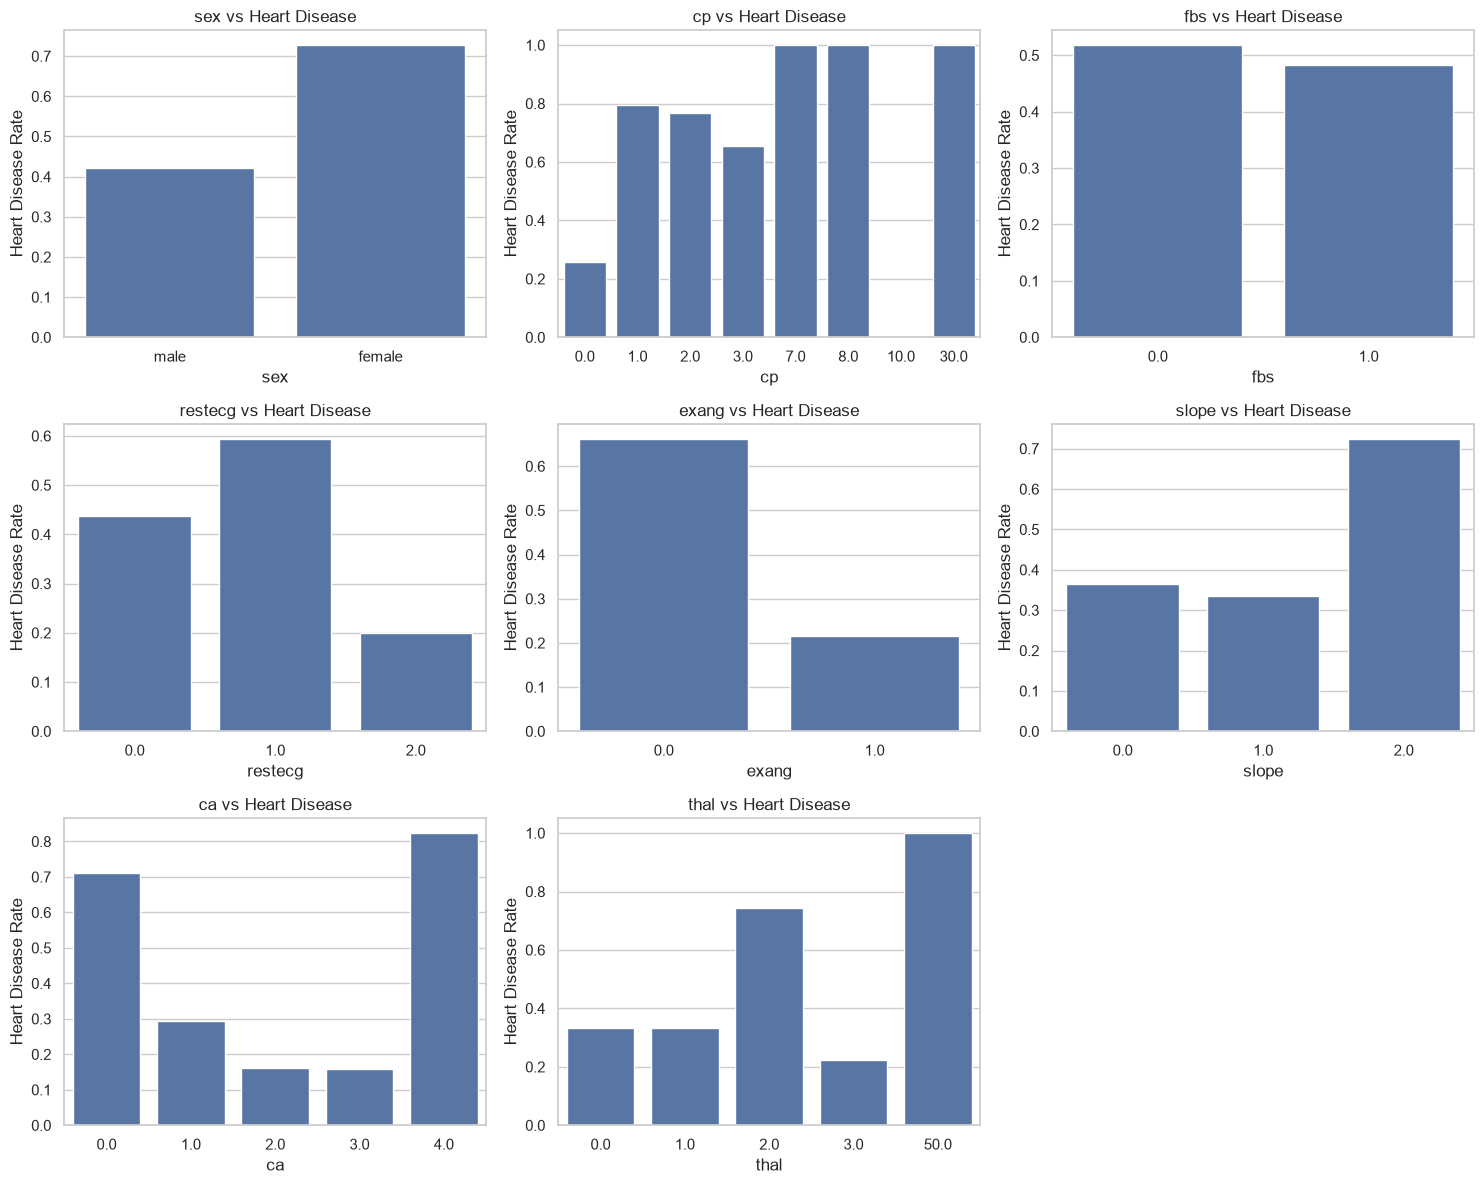

In [14]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for ax, col in zip(axes, categorical_cols):
    sns.barplot(
        data=df,
        x=col,
        y="target",
        errorbar=None,
        ax=ax
    )
    ax.set_title(f"{col} vs Heart Disease")
    ax.set_ylabel("Heart Disease Rate")
    ax.set_xlabel(col)

for ax in axes[len(categorical_cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

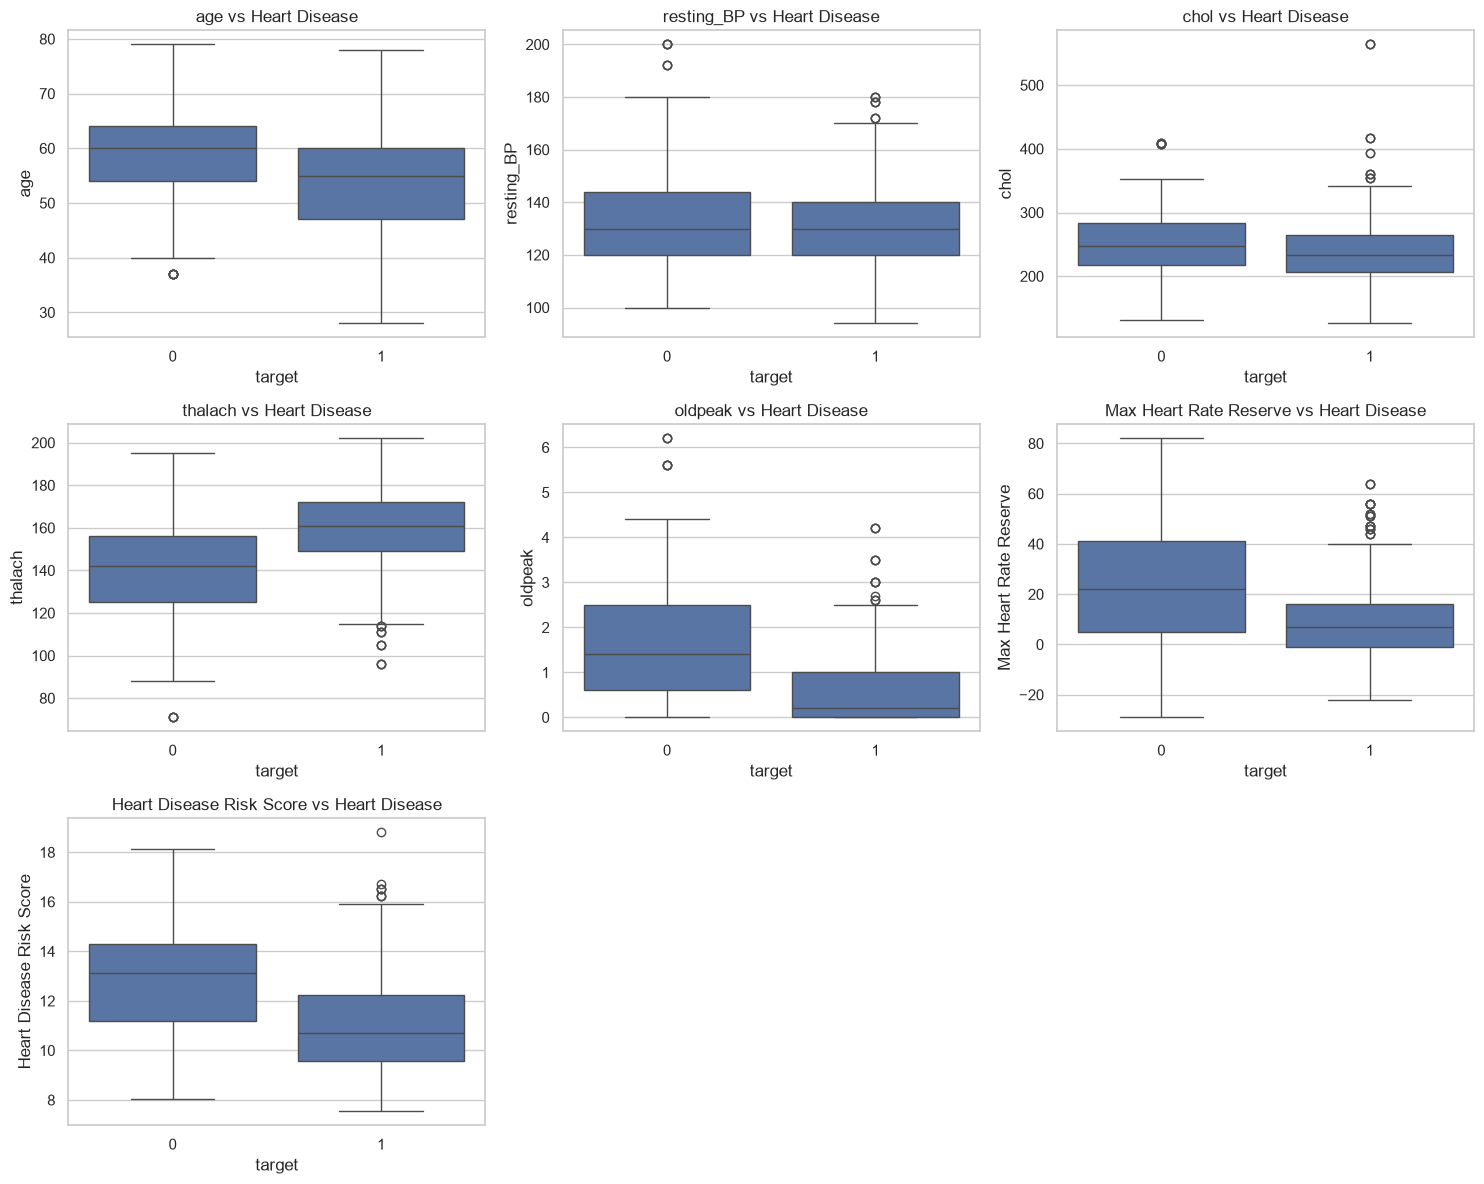

In [15]:
numeric_cols = [
    "age",
    "resting_BP",
    "chol",
    "thalach",
    "oldpeak",
    "Max Heart Rate Reserve",
    "Heart Disease Risk Score"
]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    sns.boxplot(data=df, x="target", y=col, ax=ax)
    ax.set_title(f"{col} vs Heart Disease")

for ax in axes[len(numeric_cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

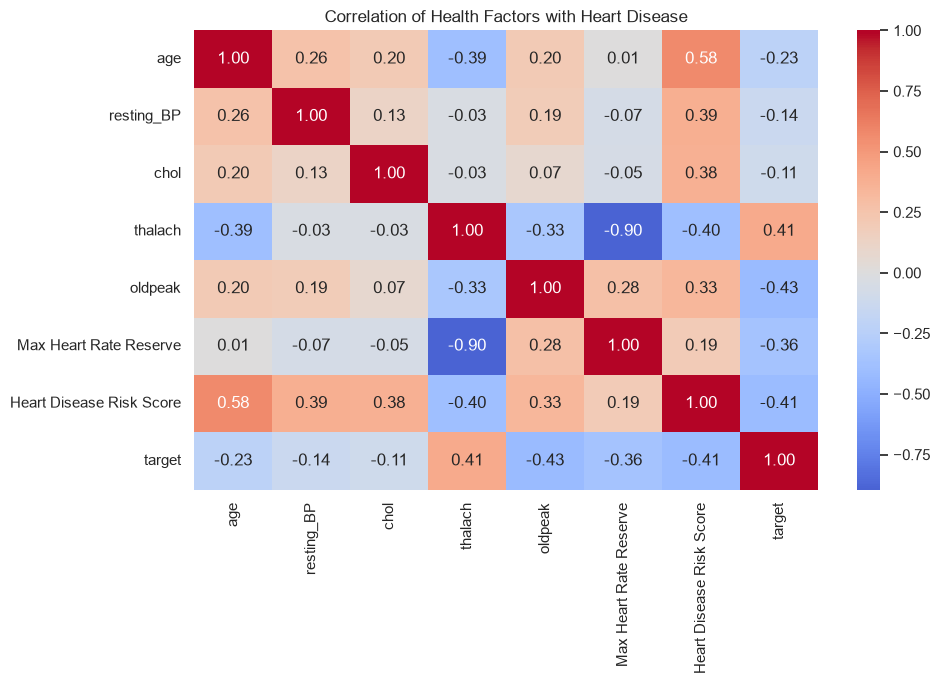

In [16]:
corr_cols = numeric_cols + ["target"]

corr = df[corr_cols].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation of Health Factors with Heart Disease")
plt.tight_layout()
plt.show()

• Detect outliers systematically (boxplot and/or IQR), and decide what to do about them.

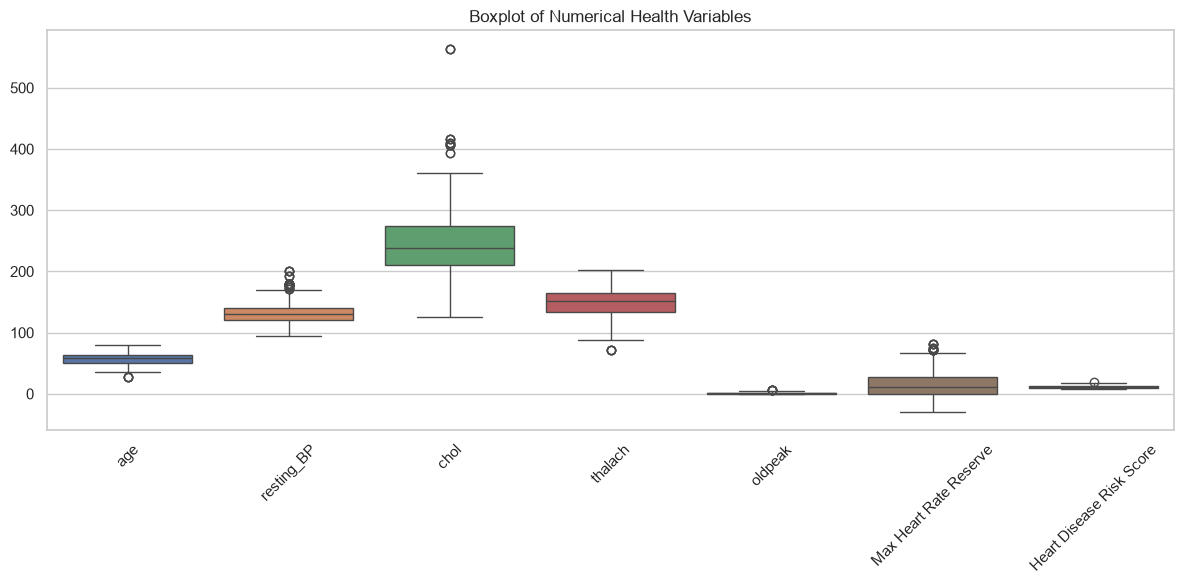

In [17]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[numeric_cols])
plt.xticks(rotation=45)
plt.title("Boxplot of Numerical Health Variables")
plt.tight_layout()
plt.show()

***TASK 03 Test two hypotheses***

• Form two specific hypotheses your data can test — for example, 'group A has a higher average Y than group B',
or 'X and Z are not independent'.

• For each, state the null hypothesis clearly in words before testing.

• Run the right test: a t-test for comparing two group averages, a chi-square for independence of two categories.

• Report the statistic and p-value, decide significance at 0.05, and — crucially — write a plain-English conclusion.

• For each result, note whether the effect is not just significant but actually large enough to matter.

In [25]:
#H₀: Chest pain type (cp) and heart disease are independent.
#H₁: Chest pain type (cp) and heart disease are not independent.

# Contingency table
table = pd.crosstab(df["cp"], df["target"])

print("Contingency Table:")
print(table)

# Chi-square test
chi2, p, dof, expected = stats.chi2_contingency(table)

print("\nChi-square statistic:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)

alpha = 0.05

if p < alpha:
    print("Reject H₀: There is a significant association between chest pain type and heart disease.")
else:
    print("Fail to reject H₀: There is not enough evidence of an association.")

#The results show a statistically significant relationship between chest pain type and heart disease.
#  This means that the pattern of chest pain types differs between patients with and without heart disease.

Contingency Table:
target    0    1
cp              
0.0     377  130
1.0      34  133
2.0      65  213
3.0      27   51
7.0       0    2
8.0       0    1
10.0      1    0
30.0      0    1

Chi-square statistic: 269.6771137304135
p-value: 1.783957406244087e-54
Degrees of freedom: 7
Reject H₀: There is a significant association between chest pain type and heart disease.


In [26]:
#H₀: The mean cholesterol level is the same for patients with and without heart disease.

#H₁: The mean cholesterol level is different for patients with and without heart disease.

# Separate the two groups
chol_no = df[df["target"] == 0]["chol"]
chol_yes = df[df["target"] == 1]["chol"]

# Independent t-test
t_stat, p_value = stats.ttest_ind(
    chol_no,
    chol_yes,
    equal_var=False
)

print("T-statistic:", t_stat)
print("p-value:", p_value)

alpha = 0.05

if p_value < alpha:
    print("Reject H₀: The mean cholesterol levels are significantly different.")
else:
    print("Fail to reject H₀: There is not enough evidence of a difference in mean cholesterol levels.")

# The results show a statistically significant difference in average cholesterol levels between patients with and without heart disease.
#  This means that cholesterol levels differ between the two heart-disease groups in this dataset.

T-statistic: 3.538428366426067
p-value: 0.0004204293433919522
Reject H₀: The mean cholesterol levels are significantly different.


***TASK 04 Produce 8+ quality visualizations***

• Build at least eight visualizations that together tell the story of your answer.

• Include a mix: univariate (distributions), bivariate (relationships), and multivariate (e.g. a correlation heatmap or a
coloured scatter).

• Every chart must have a title, labelled axes with units, and deliberate colour. No exceptions.

• Each chart should earn its place — it should reveal something, not just fill space.

• Order and arrange them so they build an argument, not a random gallery.

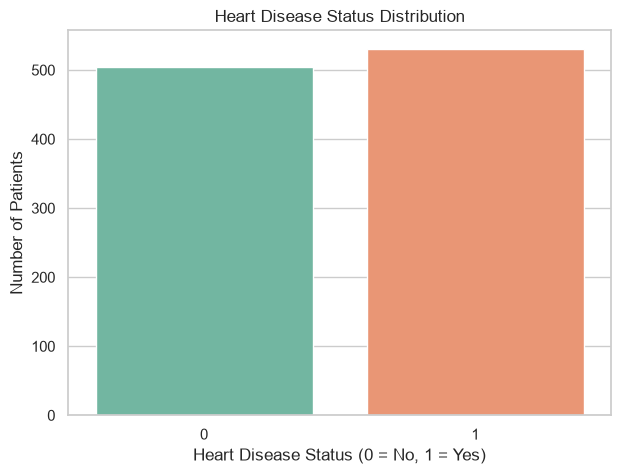

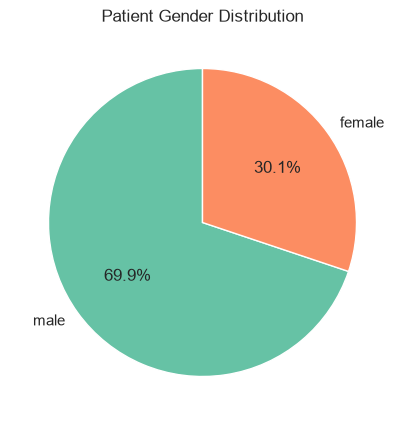

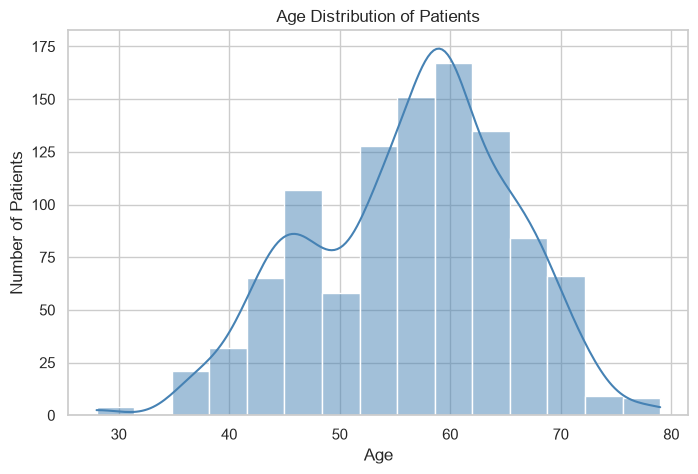

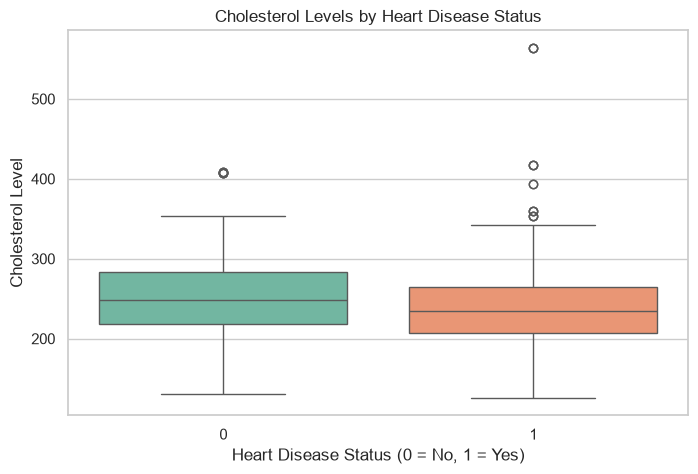

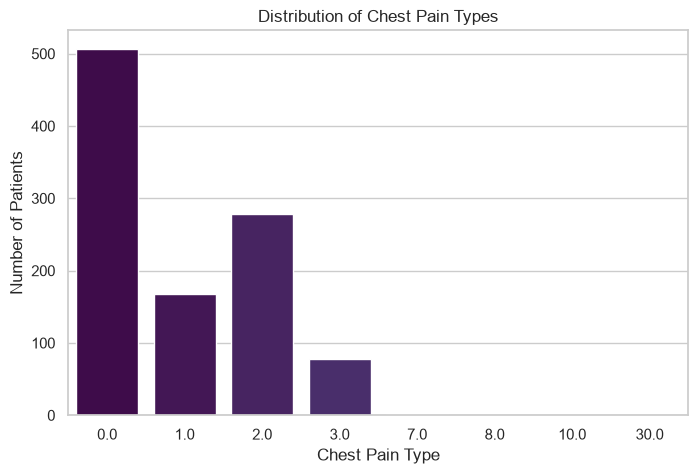

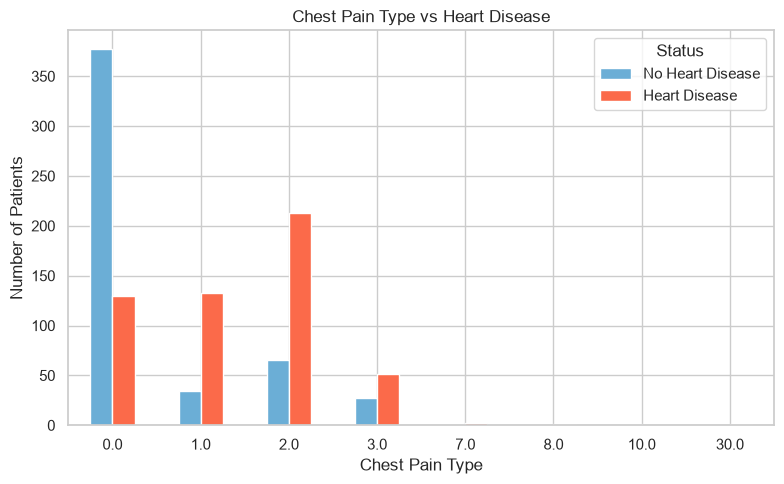

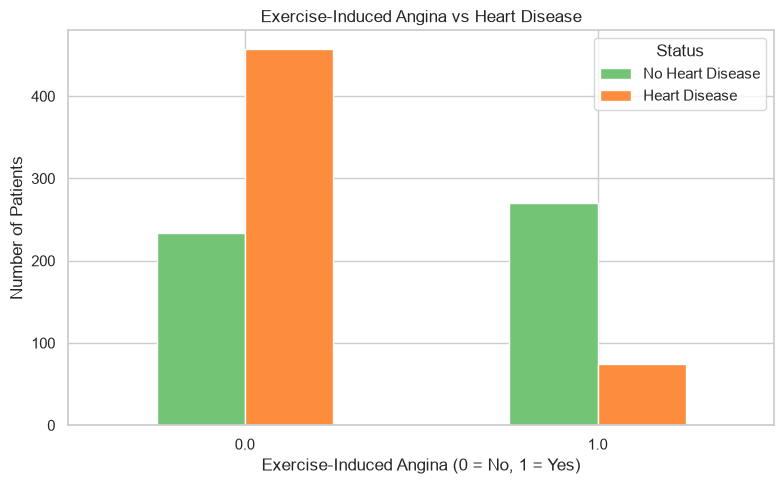

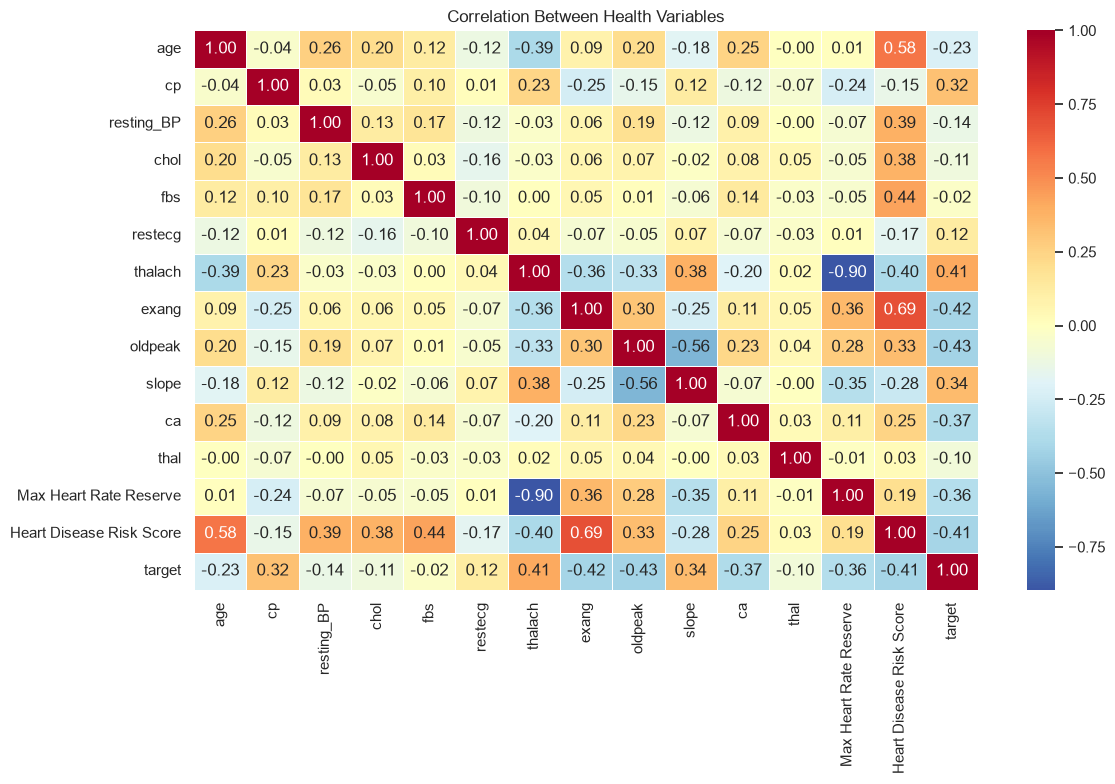

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Heart Disease Status Distribution

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="target",
    hue="target",
    palette="Set2",
    legend=False
)

plt.title("Heart Disease Status Distribution")
plt.xlabel("Heart Disease Status (0 = No, 1 = Yes)")
plt.ylabel("Number of Patients")

plt.savefig(
    "visualizations/Heart_Disease_dist.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# 2. Gender Distribution

gender_counts = df["sex"].value_counts()

plt.figure(figsize=(7, 5))

plt.pie(
    gender_counts.values,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=sns.color_palette("Set2")
)

plt.title("Patient Gender Distribution")

plt.savefig(
    "visualizations/Gender_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# 3. Age Distribution

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="age",
    bins=15,
    kde=True,
    color="steelblue"
)

plt.title("Age Distribution of Patients")
plt.xlabel("Age")
plt.ylabel("Number of Patients")

plt.savefig(
    "visualizations/Age_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# 4. Cholesterol by Heart Disease

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="target",
    y="chol",
    hue="target",
    palette="Set2",
    legend=False
)

plt.title("Cholesterol Levels by Heart Disease Status")
plt.xlabel("Heart Disease Status (0 = No, 1 = Yes)")
plt.ylabel("Cholesterol Level")

plt.savefig(
    "visualizations/Cholesterol_vs_Heart_Disease.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# 5. Chest Pain Type Distribution

cp_counts = df["cp"].value_counts().sort_index()

plt.figure(figsize=(8, 5))

sns.barplot(
    x=cp_counts.index,
    y=cp_counts.values,
    hue=cp_counts.index,
    palette="viridis",
    legend=False
)

plt.title("Distribution of Chest Pain Types")
plt.xlabel("Chest Pain Type")
plt.ylabel("Number of Patients")

plt.savefig(
    "visualizations/Chest_Pain_distribution.png",
    dpi=300, bbox_inches="tight")

plt.show()
plt.close()


# 6. Chest Pain Type vs Heart Disease

cp_target = pd.crosstab(
    df["cp"],
    df["target"]
)

cp_target.plot(
    kind="bar",
    figsize=(8, 5),
    color=["#6baed6", "#fb6a4a"]
)

plt.title("Chest Pain Type vs Heart Disease")
plt.xlabel("Chest Pain Type")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)

plt.legend(
    ["No Heart Disease", "Heart Disease"],
    title="Status"
)

plt.tight_layout()

plt.savefig(
    "visualizations/Chest_Pain_vs_Heart_Disease.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# 7. Exercise-Induced Angina vs Heart Disease

exang_target = pd.crosstab(
    df["exang"],
    df["target"]
)

exang_target.plot(
    kind="bar",
    figsize=(8, 5),
    color=["#74c476", "#fd8d3c"]
)

plt.title("Exercise-Induced Angina vs Heart Disease")
plt.xlabel("Exercise-Induced Angina (0 = No, 1 = Yes)")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)

plt.legend(
    ["No Heart Disease", "Heart Disease"],
    title="Status"
)

plt.tight_layout()

plt.savefig(
    "visualizations/Exang_vs_Heart_Disease.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# 8. Correlation Heatmap

plt.figure(figsize=(12, 8))

corr = df.select_dtypes(include="number").corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdYlBu_r",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Between Health Variables")
plt.tight_layout()

plt.savefig(
    "visualizations/Correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()